# 🏎️ F1 Race Weekend Analysis
## `Barcelona` · `2026` Formula 1 World Championship

In [1]:
# ============================================================
# CONFIGURE THESE THREE VALUES — everything else is automatic
# ============================================================
YEAR       = 2026
GRAND_PRIX = 'Barcelona'   # FastF1 event name (city or GP name)
SESSION    = 'R'           # 'R' = Race, 'Q' = Qualifying, 'S' = Sprint
# ============================================================

# Driver abbreviations for telemetry comparison (leave None for auto top-2)
DRIVER_1 = None
DRIVER_2 = None

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

from utils.f1_helpers import (
    setup, ensure_assets_dir,
    get_race_results, plot_race_results,
    plot_lap_times, plot_tyre_strategy, plot_telemetry
)
import fastf1

setup('content/f1_cache')
ASSETS = ensure_assets_dir('assets')

session = fastf1.get_session(YEAR, GRAND_PRIX, SESSION)
session.load(telemetry=True, weather=False)
print(f'\n✅ Loaded: {session.event["EventName"]} {YEAR} — {SESSION}')

core           INFO 	Loading data for Barcelona Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['44', '63', '1', '3', '81', '6', '10', '30', '41', '43', '5', '55', '31', '11', '16', '12', '87', '23', '14', '27', '77', '18']



✅ Loaded: Barcelona Grand Prix 2026 — R


---
## 1 · Race Results

In [3]:
results = get_race_results(session)
results.head(10)

,Position,FullName,TeamName,Points,Status,Time
0,1.0,Lewis Hamilton,Ferrari,25.0,Finished,0 days 01:32:28.105000
1,2.0,George Russell,Mercedes,18.0,Finished,0 days 00:00:19.561000
2,3.0,Lando Norris,McLaren,15.0,Finished,0 days 00:00:23.719000
3,4.0,Max Verstappen,Red Bull Racing,12.0,Finished,0 days 00:00:40.497000
4,5.0,Oscar Piastri,McLaren,10.0,Finished,0 days 00:00:58.661000
5,6.0,Isack Hadjar,Red Bull Racing,8.0,Lapped,0 days 00:00:24.627000
6,7.0,Pierre Gasly,Alpine,6.0,Lapped,0 days 00:00:55.789000
7,8.0,Liam Lawson,Racing Bulls,4.0,Lapped,0 days 00:01:12.224000
8,9.0,Arvid Lindblad,Racing Bulls,2.0,Lapped,0 days 00:01:18.074000
9,10.0,Franco Colapinto,Alpine,1.0,Lapped,0 days 00:01:19.867000


findfont: Failed to find font weight medium, now using 400.
req            INFO 	Using cached data for driver_info
findfont: Failed to find font weight medium, now using 400.
C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_63528\1700044813.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


Saved → assets\01_race_results.png


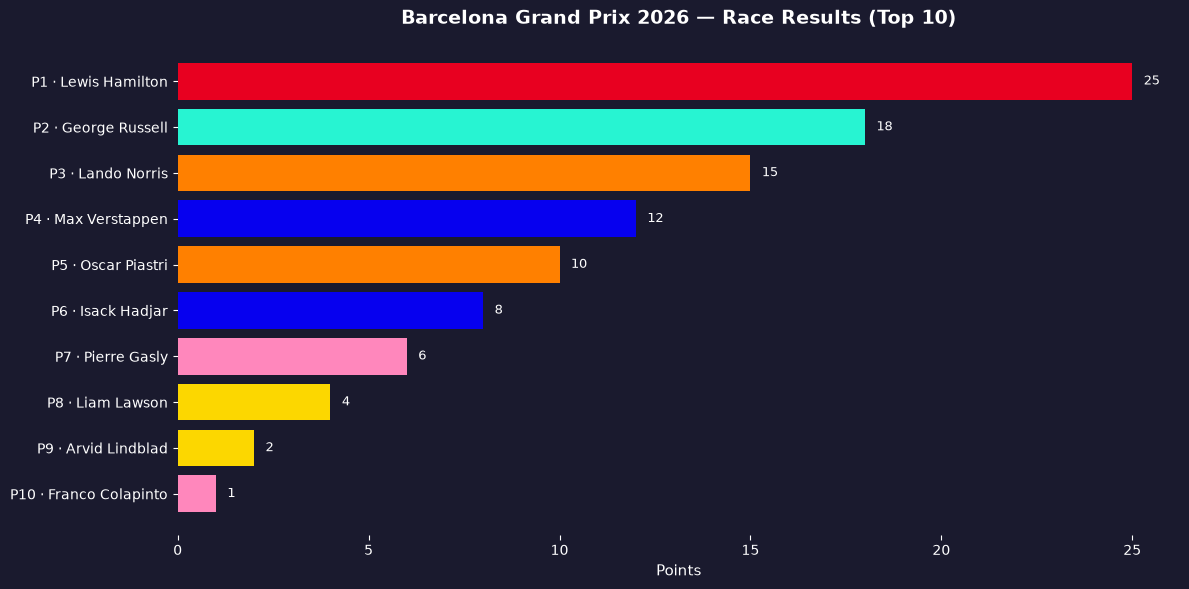

In [4]:
fig1 = plot_race_results(session, ASSETS)
fig1.show()

---
## 2 · Lap Time Evolution

e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


Saved → assets\02_lap_time_evolution.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_63528\1835926690.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


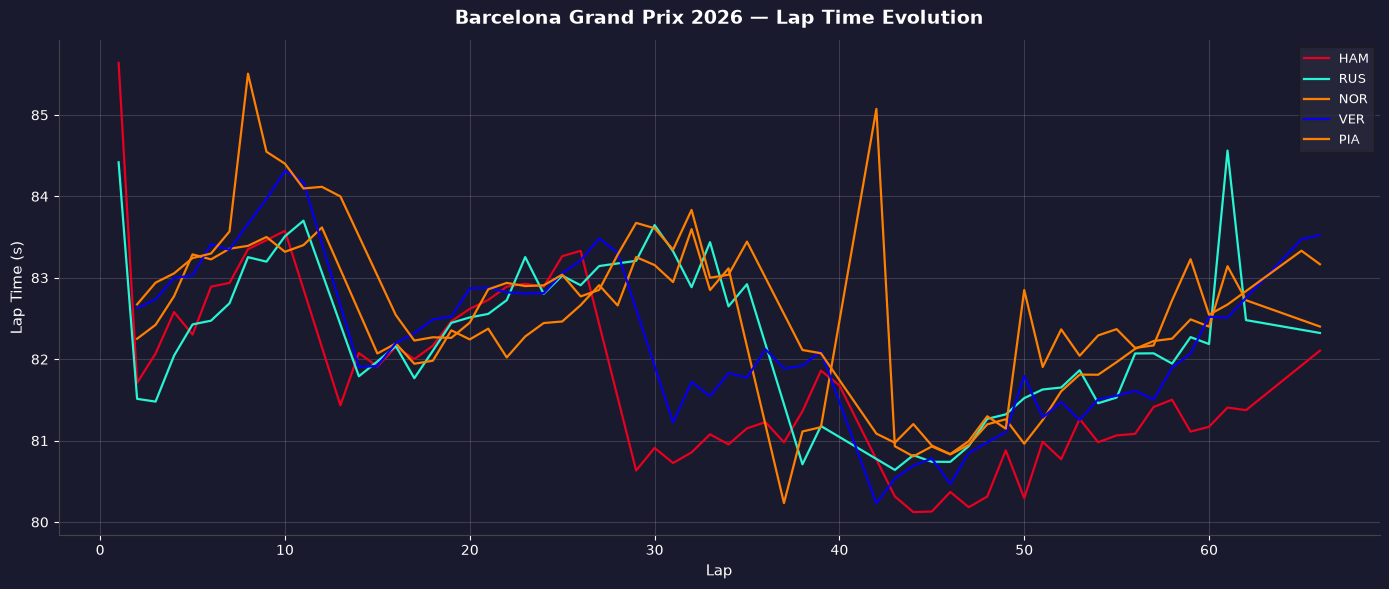

In [5]:
fig2 = plot_lap_times(session, drivers=None, assets_path=ASSETS)
fig2.show()

---
## 3 · Tyre Strategy

e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWa

Saved → assets\03_tyre_strategy.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_63528\129318135.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig3.show()


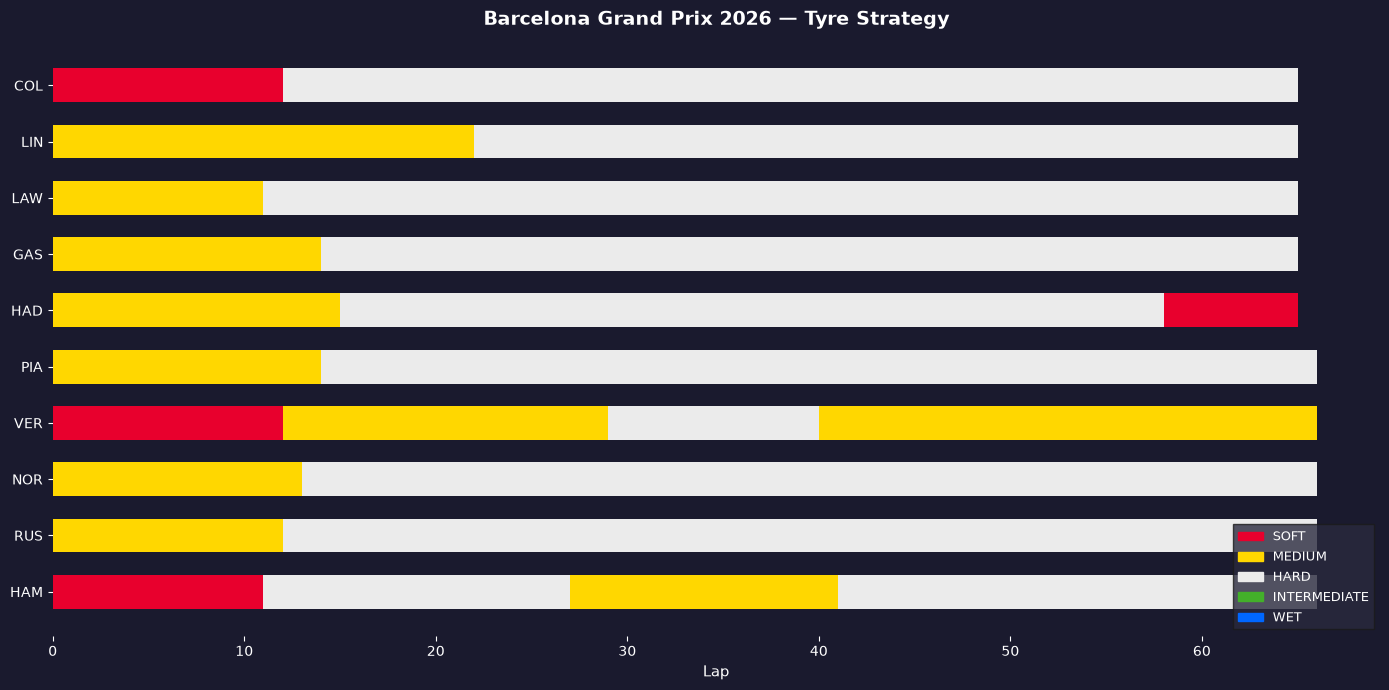

In [6]:
fig3 = plot_tyre_strategy(session, ASSETS)
fig3.show()

---
## 4 · Fastest Lap Telemetry Comparison

> Set `DRIVER_1` / `DRIVER_2` at the top to compare specific drivers (e.g., `'VER'`, `'NOR'`).  
> Leave as `None` to auto-pick P1 vs P2 finishers.

In [7]:
if DRIVER_1 is None or DRIVER_2 is None:
    top2 = results.head(2)
    DRIVER_1 = session.results[session.results['FullName'] == top2.iloc[0]['FullName']]['Abbreviation'].values[0]
    DRIVER_2 = session.results[session.results['FullName'] == top2.iloc[1]['FullName']]['Abbreviation'].values[0]

print(f'Comparing: {DRIVER_1} vs {DRIVER_2}')

Comparing: HAM vs RUS


e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


Saved → assets\04_telemetry_HAM_vs_RUS.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_63528\586320834.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig4.show()


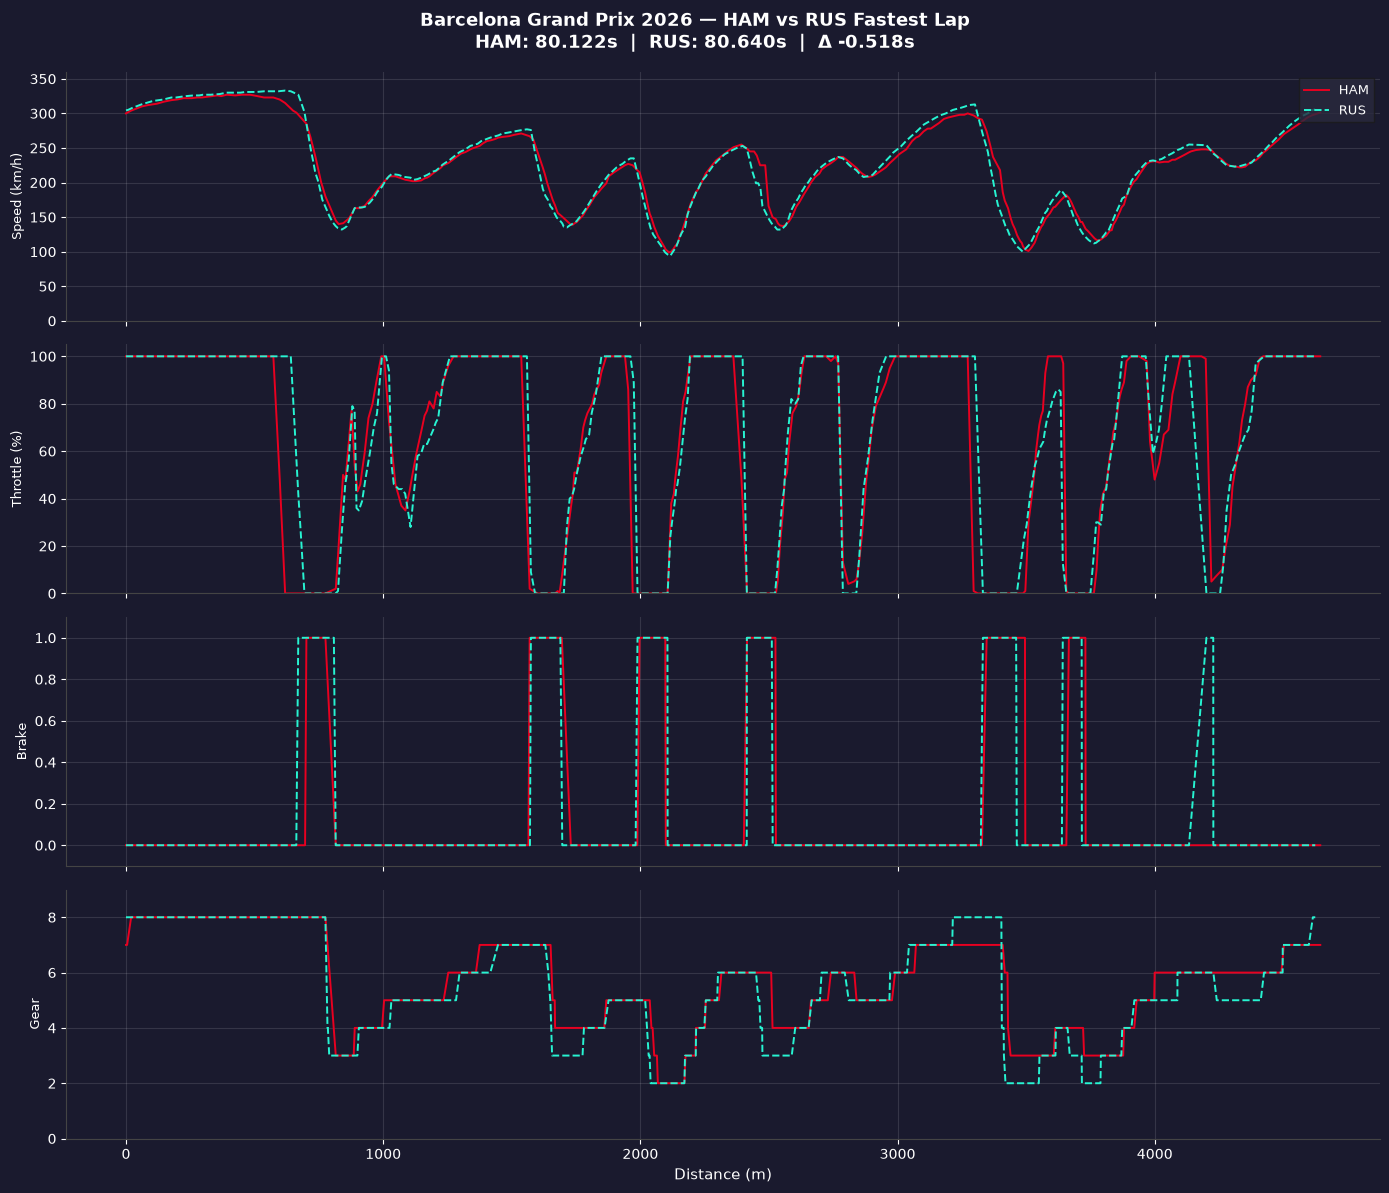

In [8]:
fig4 = plot_telemetry(session, DRIVER_1, DRIVER_2, ASSETS)
fig4.show()

---
## 5 · LinkedIn Post Draft

Fill in the template below, then copy-paste to LinkedIn.  
Attach `assets/` PNGs as images in the post (LinkedIn supports up to 9 images).

In [9]:
winner     = results.iloc[0]['FullName']
p2         = results.iloc[1]['FullName']
p3         = results.iloc[2]['FullName']
event_name = session.event['EventName']

post = f"""
🏁 {event_name} {YEAR} — What the data says

[HOOK QUESTION — e.g.: Was it strategy or pure pace that gave {winner} the win?]

📊 Race Results:
P1 {winner} · P2 {p2} · P3 {p3}

🔍 Key Findings:
1. [Finding from lap time chart]
2. [Finding from tyre strategy chart]
3. [Finding from telemetry — {DRIVER_1} vs {DRIVER_2}]

💡 Takeaway:
[1-2 sentences summarising the story of the race in data]

What was your read on the race? 👇

#Formula1 #F1 #DataAnalysis #DataScience #Motorsport #FastF1 #Python #{event_name.replace(' ', '')}
"""

print(post)


🏁 Barcelona Grand Prix 2026 — What the data says

[HOOK QUESTION — e.g.: Was it strategy or pure pace that gave Lewis Hamilton the win?]

📊 Race Results:
P1 Lewis Hamilton · P2 George Russell · P3 Lando Norris

🔍 Key Findings:
1. [Finding from lap time chart]
2. [Finding from tyre strategy chart]
3. [Finding from telemetry — HAM vs RUS]

💡 Takeaway:
[1-2 sentences summarising the story of the race in data]

What was your read on the race? 👇

#Formula1 #F1 #DataAnalysis #DataScience #Motorsport #FastF1 #Python #BarcelonaGrandPrix



---
## Assets generated

| File | Use for |
|------|---------|
| `assets/01_race_results.png` | LinkedIn image 1 — always include |
| `assets/02_lap_time_evolution.png` | LinkedIn image 2 |
| `assets/03_tyre_strategy.png` | LinkedIn image 3 — high engagement |
| `assets/04_telemetry_*.png` | LinkedIn image 4 — most technical |

**Commit checklist:**
```bash
git add 2026/R{round}_{location}/
git commit -m "feat: {event_name} {year} race analysis"
git push
```